# Quality Control Analysis

In this dataset, items are produced in batches, and each batch is evaluated using 30 quality control measurements. A batch is classified as poor quality if it contains more than one defective item.

The objective of this project is to develop a predictive model that can classify batch quality based on the results of the quality control tests. The goal is not only to make reliable predictions, but also to identify the smallest set of decision rules needed to determine batch quality. Any tests that are not used by the model may potentially be eliminated, helping reduce quality control costs while maintaining reliable inspection standards.

Step 1. Import Libraries and Load Data

In [9]:
import pandasql
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [10]:
defective = pd.read_csv('quality_control.defective.csv')
measurements = pd.read_csv('quality_control.measurements.csv')
new_batches = pd.read_csv('quality_control.new_batches.csv')

Dataframe *defective* contains the *batchID* of batches in which defective items were produced.

In [11]:
print("Dataframe defective contains %d rows and %d columns" %defective.shape)
defective.head(10)

Dataframe defective contains 12432 rows and 2 columns


,serial_nbr,batchID
0,S004B040465,B040465
1,S006B034007,B034007
2,S008B020430,B020430
3,S005B000505,B000505
4,S007B038056,B038056
5,S000B007792,B007792
6,S003B029141,B029141
7,S003B015253,B015253
8,S000B014150,B014150
9,S007B040781,B040781


Dataframe measurements contains measurements on 30 quality control tests for each batch

In [12]:
print("Dataframe measurements contains %d rows and %d columns" %measurements.shape)
measurements.head()

Dataframe measurements contains 5000 rows and 31 columns


,batchID,test1,test2,test3,test4,test5,test6,test7,test8,test9,test10,test11,test12,test13,test14,test15,test16,test17,test18,test19,test20,test21,test22,test23,test24,test25,test26,test27,test28,test29,test30
0,B020139,854,468,862,790,966,617,111,310,51,941,157,891,8,26,564,680,477,306,265,330,473,217,13,807,793,453,531,507,386,950
1,B007146,95,118,473,265,921,694,967,949,3,863,560,610,445,753,671,222,261,107,758,782,100,911,765,941,639,729,339,996,885,566
2,B020756,884,417,653,423,882,564,70,366,454,680,896,24,945,334,720,105,480,536,390,779,527,619,262,687,827,101,822,497,875,601
3,B049434,364,804,282,580,726,900,54,753,111,550,317,82,997,448,259,454,841,73,653,609,750,225,438,24,563,109,877,5,301,343
4,B035450,949,894,11,512,215,712,149,109,697,486,501,704,755,647,712,525,93,33,224,2,504,778,293,825,760,546,146,627,591,87


Step 2. Label Batch Quality

For a batch to be considered of *poor* quality, it must contain more than one defective item; otherwise, the batch quality is considered *good*.

The dataframe *defective* contains *batchID* for batches in which defective items were produced.

I will identify batches with more than one defective items using *SQL*. Then I will label each batch in the dataframe *measurements* as either a *poor* quality batch or a *good* quality batch.   




In [13]:
# define a string q with the SQL query to identify poor quality bacthers
q = """select batchID
from defective
group by batchID
having count(*) > 1;"""

poor_batches = pandasql.sqldf(q).values

print("Number of poor quality batches = %d" %len(poor_batches))

# assign labels to each batch in the dataframe measurements
labels = ['poor' if b in poor_batches else 'good'
          for b in measurements.batchID] # assign labels for batches

# create dataframe with quality of batches labeled 'poor' or 'good'
quality = pd.DataFrame(zip(measurements.batchID, labels), columns=['batchID', 'quality'])

print("Quality of first 10 batches")
quality.head(10)

Number of poor quality batches = 2488
Quality of first 10 batches


,batchID,quality
0,B020139,poor
1,B007146,poor
2,B020756,good
3,B049434,good
4,B035450,good
5,B002032,good
6,B024376,good
7,B010687,poor
8,B049981,poor
9,B002397,good


Step 3. Model training and validation  
The first 4000 samples will be used for training and the last 1000 samples for validation.

In [14]:
# all but the first column in dataframe measurements are input features
features = list(measurements)[1:] # column headers for input features
print("Number of input features = %d" %len(features))
print(', '.join(features)) # display features

k = 4000 # use first k samples for training
print("First %d samples used for training" %k)
X_train, y_train = measurements[features][:k], quality.quality[:k] # input, label for training
X_test, y_test = measurements[features][k:], quality.quality[k:] # input, label for validation

Number of input features = 30
test1, test2, test3, test4, test5, test6, test7, test8, test9, test10, test11, test12, test13, test14, test15, test16, test17, test18, test19, test20, test21, test22, test23, test24, test25, test26, test27, test28, test29, test30
First 4000 samples used for training


Cross validation accuracy

Since the goal is to achieve satisfactory classification using as few rules as possible, I will investigate how classification accuracy varies as I increase the maximum number of leaf nodes (rules)in the decision tree.

We shall use 5-fold cross-validation with the training samples for this investigation.

In [15]:
for k in range(2, 10): # maximum number of leaf-nodes (rules)
    model = DecisionTreeClassifier(max_leaf_nodes=k, min_samples_leaf=20, random_state=42) # tree with k rules
    acc = cross_val_score(model, X_train, y_train, cv=5).mean() # mean accuracy in 5-fold cross-validation
    print("Cross validation accuracy with %d rules = %4.4f" %(k, acc))

Cross validation accuracy with 2 rules = 0.6377
Cross validation accuracy with 3 rules = 0.7362
Cross validation accuracy with 4 rules = 0.8207
Cross validation accuracy with 5 rules = 0.9085
Cross validation accuracy with 6 rules = 0.9603
Cross validation accuracy with 7 rules = 0.9603
Cross validation accuracy with 8 rules = 0.9603
Cross validation accuracy with 9 rules = 0.9603


Six rules were determined to be the optimal number of rules required for the model to achieve satisfactory cross-validation accuracy while maintaining model simplicity. Increasing the number of rules beyond this point doesn't produce any performance improvements.

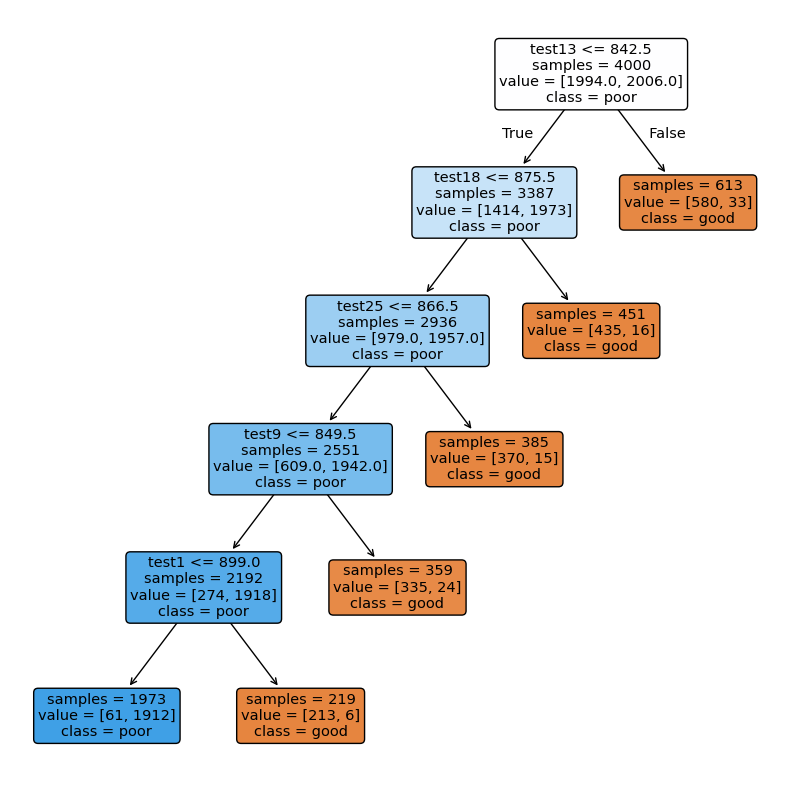

In [16]:
k = 6 # chosen number of leaf nodes
model = DecisionTreeClassifier(max_leaf_nodes=k)
model.fit(X_train, y_train)

plt.figure(figsize=(10, 10))

CL = model.classes_
plot_tree(model, feature_names=features, class_names=CL,
          filled=True, rounded=True, impurity=False)

plt.savefig("decision_tree.png")
plt.show()

Model performance analysis on training data

In [17]:
pred_train = model.predict(X_train) # predicted labels for training samples
acc_train = accuracy_score(y_train, pred_train) # training accuracy
print("Training accuracy  = %4.4f" %(acc_train))
# confusion matrix
cm = pd.DataFrame(confusion_matrix(y_train, pred_train), columns=[f'Predicted {c}' for c in CL], index=CL)
#cm.to_csv('training_confusion_matrix.csv') # save confusion matrix
cm

Training accuracy  = 0.9613


,Predicted good,Predicted poor
good,1933,61
poor,94,1912


In [18]:
print(classification_report(y_train, pred_train, digits=4))

              precision    recall  f1-score   support

        good     0.9536    0.9694    0.9615      1994
        poor     0.9691    0.9531    0.9610      2006

    accuracy                         0.9613      4000
   macro avg     0.9614    0.9613    0.9612      4000
weighted avg     0.9614    0.9613    0.9612      4000



Model performance analysis on validation data

In [19]:
pred_test = model.predict(X_test) # predicted labels for validation samples
acc_test = accuracy_score(y_test, pred_test) # validation accuracy
print("Validation accuracy  = %4.4f" %(acc_test))
cm = pd.DataFrame(confusion_matrix(y_test, pred_test), columns=[f'Predicted {c}' for c in CL], index=CL)
#cm.to_csv('validation_confusion_matrix.csv')
cm

Validation accuracy  = 0.9990


,Predicted good,Predicted poor
good,518,0
poor,1,481


In [20]:
print(classification_report(y_test, pred_test, digits=4))

              precision    recall  f1-score   support

        good     0.9981    1.0000    0.9990       518
        poor     1.0000    0.9979    0.9990       482

    accuracy                         0.9990      1000
   macro avg     0.9990    0.9990    0.9990      1000
weighted avg     0.9990    0.9990    0.9990      1000



Step 4. Predict quality for unlabeled samples

In [21]:
new_labels = pd.DataFrame()
new_labels['batchID'] = new_batches.batchID
new_labels['quality'] = model.predict(new_batches[features])
#new_labels.to_csv("new_labels.csv", index=False)
new_labels

,batchID,quality
0,B045918,good
1,B043908,good
2,B027243,good
3,B025639,good
4,B013471,good
5,B005616,good
6,B029063,good
7,B047644,good
8,B041615,good
9,B004960,good


## Feature importances

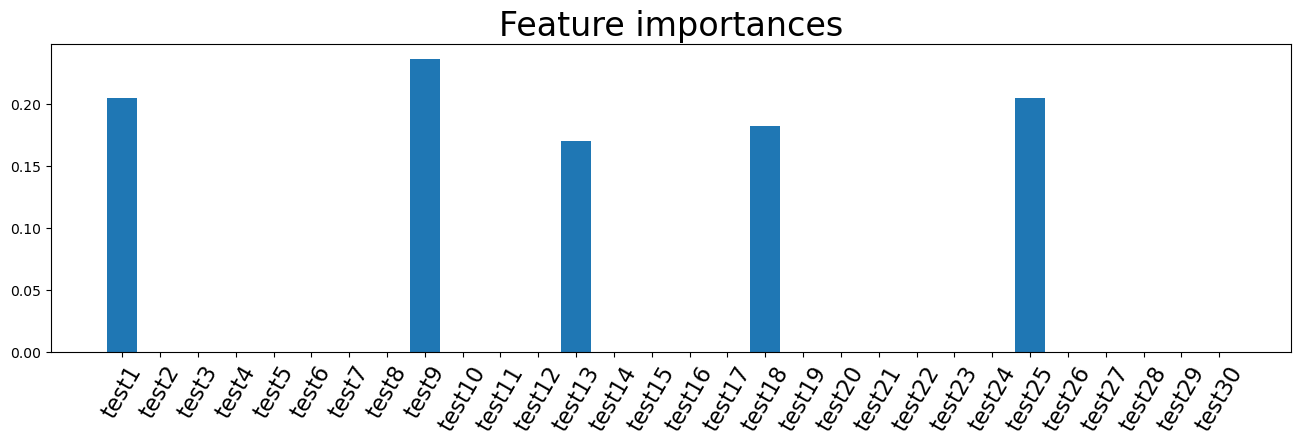

In [22]:
plt.figure(figsize=(16, 4)) # size of figure to be displayed
plt.bar(features, model.feature_importances_)
plt.xticks(rotation = 60, fontsize=16)
plt.title('Feature importances', fontsize=24)
plt.show()

Based on the analysis and optimization of the quality control process, the model indicates that only tests 1, 9, 13, 18, and 25 are required to reliably predict batch quality. The remaining 25 tests didn't contribute to the predictive process and may therefore be eliminated, potentially reducing inspection time and overall quality control costs while maintaining satisfactory prediction performance.